In [ ]:
print("Chapter 3 Classification Hands on ML boook")

Chapter 3 Classification Hands on ML boook


In [ ]:
from tensorflow.keras.datasets import mnist
import numpy as np

(X_train, y_train), (X_test, y_test) = mnist.load_data()

# Combine train and test
X = np.concatenate([X_train, X_test], axis=0)
y = np.concatenate([y_train, y_test], axis=0)

# Flatten 28x28 images to 784 features
X = X.reshape(-1, 784)

print(X.shape)
print(y.shape)

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
(70000, 784)
(70000,)


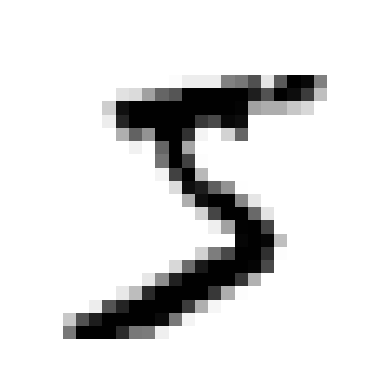

In [ ]:
import matplotlib as mpl
import matplotlib.pyplot as plt
some_digit = X[0]
some_digit_image = some_digit.reshape(28, 28)
plt.imshow(some_digit_image, cmap="binary")
plt.axis("off")
plt.show()

In [ ]:
y[0]

np.uint8(5)

In [ ]:
y = y.astype(np.uint8)

In [ ]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

### training a binary classifier

In [ ]:
y_train_5 = (y_train == 5)  # True for all 5s, False for all other digits
y_test_5 = (y_test == 5)

In [ ]:
from sklearn.linear_model import SGDClassifier
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train_5)

SGDClassifier(random_state=42)

In [ ]:
sgd_clf.predict([some_digit])

array([ True])

In [ ]:
#Evaluating classification models is much harder than evaluating regression models.

In [ ]:
#classification problem need more than accuracy, it needs precision and recall also

# Implementing Cross Validation

In [ ]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone
skfolds = StratifiedKFold(n_splits=3)
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]
    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))


#This code is performing 3-fold stratified cross-validation manually. It is doing the same thing that cross_val_score() does behind the scenes.

0.95035
0.96035
0.9604


we can do it with predefined syntax also

In [ ]:
from sklearn.model_selection import cross_val_score

cross_val_score(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    scoring="accuracy"
)

array([0.95035, 0.96035, 0.9604 ])

In [ ]:
#but in terms of classification accuracy can be misleading,

Accuracy can be misleading in imbalanced datasets because a model can achieve high accuracy by simply predicting the majority class while completely failing to identify the minority class.

EG:-90% images = Not 5
10% images = 5

A classifier that always predicts "Not 5" gets 90% accuracy but never detects a single 5.

Takeaway: High accuracy does not always mean a good classifier; metrics like precision, recall, and F1-score are often more informative for imbalanced datasets.

For imbalanced classification problems:


Precision
Recall
F1 Score
Confusion Matrix
ROC Curve

In [ ]:
from sklearn.base import BaseEstimator

class Never5Classifier(BaseEstimator):
  def fit(self, X, y=None):
      return self
  def predict(self, X):
      return np.zeros((len(X), 1), dtype=bool)

In [ ]:
never_5_clf = Never5Classifier()
cross_val_score(never_5_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.91125, 0.90855, 0.90915])

In [ ]:
#here we have seen that it is doing nothing still we are getting 90 percent accuracy so we can clearly say accuracy is not sufficient for classification problem

Solution:-Confusion Matrix

In [ ]:
from sklearn.model_selection import cross_val_predict
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

cross_val_predict returns the predictions made on each test fold instead of evaluation scores

In [ ]:
 from sklearn.metrics import confusion_matrix
 confusion_matrix(y_train_5, y_train_pred)

array([[53892,   687],
       [ 1891,  3530]])

In [ ]:
y_train_perfect_predictions = y_train_5 #pretend we reach perfection then we will get only TP and TN
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

## Precision and Recall

In [ ]:
from sklearn.metrics import precision_score, recall_score
precision_score(y_train_5, y_train_pred)

0.8370879772350012

See where accuracy was 90 % above now we with precision we get to know that , out of all predictions only 82% are correct

In [ ]:
recall_score(y_train_5, y_train_pred)

0.6511713705958311

See out of all actual true valeus, we found onl 65%

which clearly says imporatance of thes parameters other than accuracy

# F1 Score

In [ ]:
from sklearn.metrics import f1_score
f1_score(y_train_5, y_train_pred)

0.7325171197343847

we think that .predict will give either true or false but internally it happens in two steps

first it calculates score and then check if score> threshold

below are the code


In [ ]:
y_scores = sgd_clf.decision_function([some_digit]) # calculating score with help of decision function
y_scores

array([2164.22030239])

In [ ]:
#defining threshold
threshold = 0
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([ True])

In [ ]:
#changing threshold

threshold = 8000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

Find best threshold

In [ ]:
y_scores = cross_val_predict(
    sgd_clf,
    X_train,
    y_train_5,
    cv=3,
    method="decision_function"
)

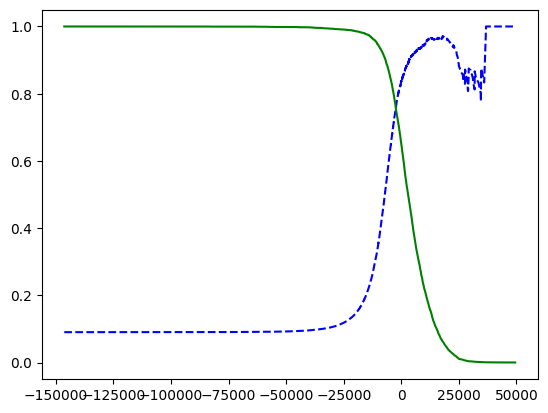

In [ ]:
from sklearn.metrics import precision_recall_curve
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)

def plot_precision_recall_vs_threshold(precisions, recalls, thresholds):
    plt.plot(thresholds, precisions[:-1], "b--", label="Precision")
    plt.plot(thresholds, recalls[:-1], "g-", label="Recall")
    [...] # highlight the threshold and add the legend, axis label, and grid
plot_precision_recall_vs_threshold(precisions, recalls, thresholds)
plt.show()

Even if precision is high mdoel has no use if recall is low

In [ ]:
threshold_90_precision = thresholds[np.argmax(precisions >= 0.90)]
y_train_pred_90 = (y_scores >= threshold_90_precision)

In [ ]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [ ]:
recall_score(y_train_5, y_train_pred_90)

0.4799852425751706

# ROC Curve

In [ ]:
from sklearn.metrics import roc_curve

fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

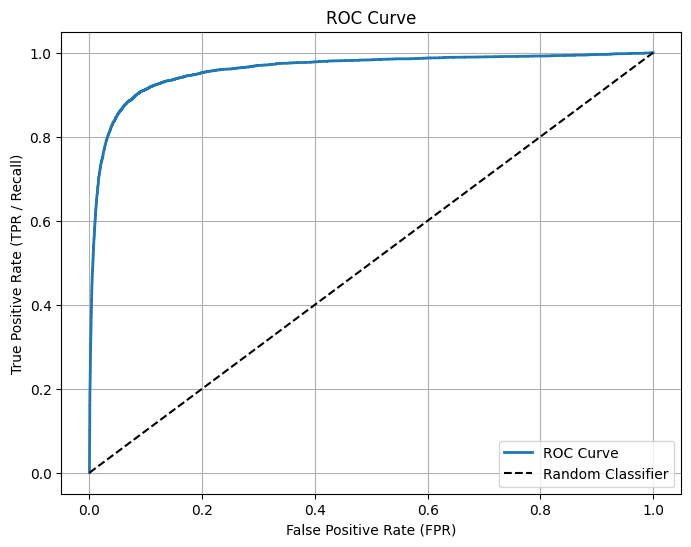

In [ ]:
def plot_roc_curve(fpr, tpr, label=None):
    plt.figure(figsize=(8, 6))

    # ROC curve
    plt.plot(fpr, tpr, linewidth=2, label=label if label else "ROC Curve")

    # Random classifier line
    plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")

    # Labels and formatting
    plt.xlabel("False Positive Rate (FPR)")
    plt.ylabel("True Positive Rate (TPR / Recall)")
    plt.title("ROC Curve")
    plt.grid(True)
    plt.legend(loc="lower right")

    plt.show()

plot_roc_curve(fpr, tpr)

In [ ]:
from sklearn.metrics import roc_auc_score
roc_auc_score(y_train_5, y_scores)

np.float64(0.9604938554008616)

ROC curve can also be misleading

When positive class is rare:-use Precison Recall curve

otherwise use ROC curve

In [ ]:
# ROC can look overly optimistic when the positive class is rare because
#  FPR is divided by a huge number of negatives. Precision-Recall
#  curves reveal the real cost of false positives and are therefore
#  usually more informative for imbalanced datasets.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
forest_clf = RandomForestClassifier(random_state=42)
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

Random Forest Classifier does not have decision function so how decision functio

so it use probability instead of score

In [ ]:
y_scores_forest = y_probas_forest[:, 1]   # score = proba of positive class
fpr_forest, tpr_forest, thresholds_forest = roc_curve(y_train_5,y_scores_forest)

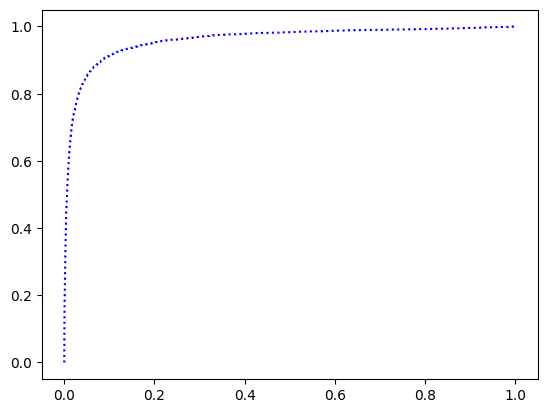

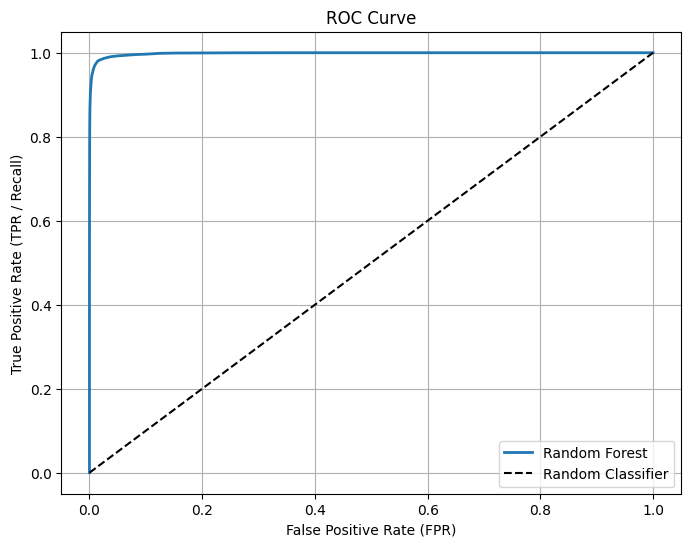

/tmp/ipykernel_3795/2570309076.py:3: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(loc="lower right")


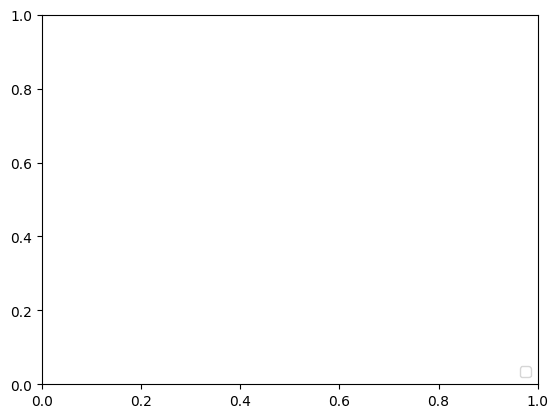

In [ ]:
plt.plot(fpr, tpr, "b:", label="SGD")
plot_roc_curve(fpr_forest, tpr_forest, "Random Forest")
plt.legend(loc="lower right")
plt.show()

In [ ]:
# Random Forest classifier is superior to the SGD
# classifier because its ROC curve is much closer to the top-left corner,
#  and it has a greater
# AUC

In [ ]:
roc_auc_score(y_train_5, y_scores_forest)

np.float64(0.9983436731328145)

# **Multiclass Classifier**

In [ ]:
from sklearn.svm import SVC
svm_clf = SVC()
svm_clf.fit(X_train, y_train) # y_train, not y_train_5
svm_clf.predict([some_digit])

array([5], dtype=uint8)

SVC is classification of SVM and mnist is multi class dataset

When you pass multi-class labels to a binary algorithm:

👉 Scikit-learn automatically wraps it using a strategy.

For SVC specifically:

🔥 It uses One-vs-One (OvO

In [ ]:
#decison function

some_digit_scores = svm_clf.decision_function([some_digit])
some_digit_scores

array([[ 1.72501977,  2.72809088,  7.2510018 ,  8.3076379 , -0.31087254,
         9.3132482 ,  1.70975103,  2.76765202,  6.23049537,  4.84771048]])

In [ ]:
np.argmax(some_digit_scores)

np.int64(5)

In [ ]:
svm_clf.classes_

array([0, 1, 2, 3, 4, 5, 6, 7, 8, 9], dtype=uint8)

In [ ]:
svm_clf.classes_[5]

np.uint8(5)

In [ ]:
from sklearn.linear_model import SGDClassifier

sgd_clf = SGDClassifier(verbose=1)
sgd_clf.fit(X_train, y_train)

In [ ]:
sgd_clf.decision_function([some_digit])

array([[-25236.23958575, -22432.16542018, -10235.00473885,
          -661.31862798, -24213.2873384 ,  -1445.62221529,
        -25478.17282614, -14057.78717621,  -6618.18581212,
         -9431.52676934]])

# *Multilabel Classification*

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
y_train_large = (y_train >= 7)
y_train_odd = (y_train % 2 == 1)
y_multilabel = np.c_[y_train_large, y_train_odd]
knn_clf = KNeighborsClassifier()
knn_clf.fit(X_train, y_multilabel)

KNeighborsClassifier()

In [ ]:
knn_clf.predict([some_digit])

array([[False,  True]])

In [ ]:
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)
f1_score(y_multilabel, y_train_knn_pred, average="macro")

0.9764102655606048

# **MultiOutput Classification**

In [ ]:
#takin noising data

#building a system that takes a noisy image → outputs a clean image

noise = np.random.randint(0, 100, (len(X_train), 784))
X_train_mod = X_train + noise
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise
y_train_mod = X_train
y_test_mod = X_test

In [ ]:
def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary")
    plt.axis("off")
    plt.show()

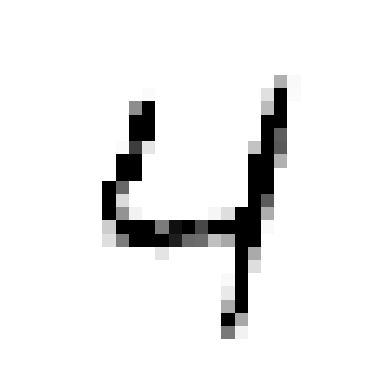

In [ ]:
some_index = 4
knn_clf.fit(X_train_mod, y_train_mod)
clean_digit = knn_clf.predict([X_test_mod[some_index]])
plot_digit(clean_digit)
